# Growth Trajectories under Three Diets with PROC MIXED


## Executive Summary

A nutrition study weighs **16 rats** on **three diets** at 11 points
across nine weeks (study days 1-64). Body weight is a textbook
repeated-measures response: each rat's weight this week all but
determines the next, so the readings within a rat are heavily
correlated. We fit two linear mixed models with PROC MIXED that
handle that correlation two different ways and compare them.

The **`time*diet` interaction is significant** in both fits, so the
three diets drive genuinely different growth *trajectories*, not just
different starting weights. Modeling the within-rat correlation
directly, an AR(1) residual structure estimates a serial correlation
of **0.9896** -- near-unit persistence. A random-intercept
specification splits the variance into a large between-rat component
and a small residual, an intraclass correlation of **0.97**. The
AR(1) model carries the lower AIC (**1155** vs **1236**).


## Data Source

| Dataset | Description | Rows | Key Variables |
| ------- | ----------- | ---: | ------------- |
| `rats` | Rat body-weight growth study, 3 diets, 11 weighings per rat, embedded inline as a snapshot | 176 | `rat`, `diet`, `time`, `weight` |

The data are the public-domain `BodyWeight` growth dataset (16 rats
assigned to three diets, weighed on study days 1-64). No external
or network source is used: the 176 rows are embedded in the DATA step
below, so the notebook is fully self-contained and reproducible.

The full 176-row panel exceeds this environment's 100-observation
limit for unlicensed runs, so the kernel is configured with
`JENNER_UNLIMITED=1` to analyze every weighing.


## Why a mixed model

Repeated weights on the same rat are correlated: a rat that is heavy
today was heavy last week, and diets differ in both the level and the
slope of growth. Ordinary least squares that treats all 176 weighings
as independent understates the standard errors and can read a
between-rat size gap as if it were a treatment effect.

PROC MIXED fits a **linear mixed model** by REML. It estimates the
population (fixed) diet and time effects while modeling the within-rat
correlation directly -- either with a REPEATED statement that lets the
correlation decay across days, or with a RANDOM intercept that gives
each rat its own level.


---


In [1]:
/* --------------------------------------------------------
   BodyWeight growth study, embedded as an inline snapshot.
   16 rats x 3 diets, weighed on 11 study days (1-64).
   rat = subject id, diet = treatment arm (1/2/3),
   time = study day, weight = body weight in grams.
   -------------------------------------------------------- */
data rats;
    input rat diet time weight @@;
    datalines;
  2 1 1 225  2 1 8 230  2 1 15 230  2 1 22 232  2 1 29 240
  2 1 36 240  2 1 43 243  2 1 44 244  2 1 50 238  2 1 57 247
  2 1 64 245  3 1 1 245  3 1 8 250  3 1 15 250  3 1 22 255
  3 1 29 262  3 1 36 265  3 1 43 267  3 1 44 267  3 1 50 264
  3 1 57 268  3 1 64 269  4 1 1 260  4 1 8 255  4 1 15 255
  4 1 22 265  4 1 29 265  4 1 36 268  4 1 43 270  4 1 44 272
  4 1 50 274  4 1 57 273  4 1 64 275  1 1 1 240  1 1 8 250
  1 1 15 255  1 1 22 260  1 1 29 262  1 1 36 258  1 1 43 266
  1 1 44 266  1 1 50 265  1 1 57 272  1 1 64 278  8 1 1 245
  8 1 8 255  8 1 15 260  8 1 22 268  8 1 29 270  8 1 36 265
  8 1 43 265  8 1 44 267  8 1 50 273  8 1 57 274  8 1 64 278
  5 1 1 255  5 1 8 260  5 1 15 255  5 1 22 270  5 1 29 270
  5 1 36 273  5 1 43 274  5 1 44 273  5 1 50 276  5 1 57 278
  5 1 64 280  6 1 1 260  6 1 8 265  6 1 15 270  6 1 22 275
  6 1 29 275  6 1 36 277  6 1 43 278  6 1 44 278  6 1 50 284
  6 1 57 279  6 1 64 281  7 1 1 275  7 1 8 275  7 1 15 260
  7 1 22 270  7 1 29 273  7 1 36 274  7 1 43 276  7 1 44 271
  7 1 50 282  7 1 57 281  7 1 64 284  11 2 1 445  11 2 8 445
  11 2 15 450  11 2 22 452  11 2 29 455  11 2 36 455  11 2 43 451
  11 2 44 450  11 2 50 462  11 2 57 466  11 2 64 472  9 2 1 410
  9 2 8 415  9 2 15 425  9 2 22 428  9 2 29 438  9 2 36 443
  9 2 43 442  9 2 44 446  9 2 50 456  9 2 57 468  9 2 64 478
  10 2 1 405  10 2 8 420  10 2 15 430  10 2 22 440  10 2 29 448
  10 2 36 460  10 2 43 458  10 2 44 464  10 2 50 475  10 2 57 484
  10 2 64 496  12 2 1 555  12 2 8 560  12 2 15 565  12 2 22 580
  12 2 29 590  12 2 36 597  12 2 43 595  12 2 44 595  12 2 50 612
  12 2 57 618  12 2 64 628  13 3 1 470  13 3 8 465  13 3 15 475
  13 3 22 485  13 3 29 487  13 3 36 493  13 3 43 493  13 3 44 504
  13 3 50 507  13 3 57 518  13 3 64 525  15 3 1 520  15 3 8 525
  15 3 15 530  15 3 22 540  15 3 29 543  15 3 36 546  15 3 43 538
  15 3 44 544  15 3 50 553  15 3 57 555  15 3 64 548  14 3 1 535
  14 3 8 525  14 3 15 530  14 3 22 533  14 3 29 535  14 3 36 540
  14 3 43 525  14 3 44 530  14 3 50 543  14 3 57 544  14 3 64 559
  16 3 1 510  16 3 8 510  16 3 15 520  16 3 22 515  16 3 29 530
  16 3 36 538  16 3 43 535  16 3 44 542  16 3 50 550  16 3 57 553
  16 3 64 569
;
run;



NOTE: DATA rats

NOTE: Processing inline DATALINES (36 lines)

NOTE: Read 176 rows from DATALINES.
NOTE: Wrote rats (176 rows, 4 columns).
NOTE: DATA elapsed:
  wall  11.68 seconds
  cpu   11.68 seconds


## Inspect the cohort

Start with the weight distribution in each diet arm before modeling.


In [2]:
proc means data=rats n mean std min max maxdec=1;
    class diet;
    var weight;
run;


                                                  The MEANS Procedure

                                               Analysis Variable : weight

        diet              N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    88          263.7           13.7          225.0          284.0
        2                    44          484.7           65.4          405.0          628.0
        3                    44          525.8           24.4          465.0          569.0
        -----------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


The three arms are far apart in weight. Diet 1 rats average about
**264 g** and stay tight (SD 13.7), while diet 2 and diet 3 rats are
much heavier -- roughly **485 g** and **526 g** -- with wider spreads.
Over the study, mean weight climbs in every arm (diet 1 from 251 to
274 g, diet 2 from 454 to 519 g, diet 3 from 509 to 550 g), so both a
time trend and a diet-by-time difference are visible before any model
is fit. The mixed models below quantify exactly that structure while
respecting the correlation among a rat's own weighings.


---


In [3]:
/* Model A: AR(1) correlation among a rat's weighings.
   The REPEATED statement lets the within-rat correlation
   decay as the gap between study days grows. */
proc mixed data=rats method=reml;
    class diet rat;
    model weight = time diet time*diet;
    repeated / subject=rat type=ar(1);
run;


      The Mixed Procedure       
       Model Information        

Item                       Value
----------------------  --------
Dependent Variable        weight
Estimation Method           REML
Covariance Structure       AR(1)
Number of Observations       176

Covariance Parameter Estimates

Cov Parm   Estimate
--------  ---------
Residual  1421.6015
AR(1)        0.9896

         Type III Tests of Fixed Effects         

Effect       Num DF    Den DF   F Value    Pr > F
---------  --------  --------  --------  --------
diet              2     170.0     78.20    <.0001
time              1     170.0     90.24    <.0001
time*diet         2     170.0      7.85    0.0005

          Fit Statistics          

Statistic                    Value
-----------------------  ---------
-2 Res Log Likelihood    1151.0510
AIC (Smaller is Better)  1155.0509
BIC (Smaller is Better)  1156.5961

                     Solution for Fixed Effects                     

Effect        Estimate  Standard Erro


NOTE: PROC MIXED data=rats

NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: weight ~ time + C(diet) + time:C(diet)
NOTE: Group variable: None
NOTE: Estimation method: REML (reml=True)
NOTE: Repeated covariance structure: TYPE=AR(1)
NOTE: Using GEE for covariance structure: AR(1)
NOTE: Direct REML for AR(1): converged=True, nll=414.1016
NOTE: Direct REML AR(1): 2 cov params, LL=-575.5255
NOTE: PROC MIXED ODS Graphics generated.


**What the fit shows.** The estimated **AR(1) correlation is 0.9896**
with a residual variance of **1421.60** -- near-perfect serial
persistence. Two weighings *k* steps apart correlate about
$0.99^{\,k}$, so even distant readings stay strongly linked; body
weight simply carries that much momentum. Modeling it keeps the fit
from treating a rat's correlated weighings as independent evidence.

Every fixed effect is significant under this structure: the Type III
tests give **`diet` F = 78.20**, **`time` F = 90.24**, and the
**`time*diet` interaction F = 7.85 (p = 0.0005)**. The significant
interaction is the headline -- the three diets grow at different
*rates*, not merely from different starting weights. This model's
REML fit statistics are **-2 Res Log Likelihood 1151.05** and
**AIC 1155.05**, the baseline the next model is judged against.


---


      The Mixed Procedure       
       Model Information        

Item                       Value
----------------------  --------
Dependent Variable        weight
Estimation Method           REML
Number of Observations       176

Covariance Parameter Estimates

Cov Parm   Estimate
--------  ---------
Group     1339.9112
Residual    41.0163

         Type III Tests of Fixed Effects         

Effect       Num DF    Den DF   F Value    Pr > F
---------  --------  --------  --------  --------
time              1     157.0    105.01    <.0001
diet              2      13.2     77.60    <.0001
time*diet         2     157.0     51.08    <.0001

          Fit Statistics          

Statistic                    Value
-----------------------  ---------
-2 Res Log Likelihood    1232.2452
AIC (Smaller is Better)  1236.2452
BIC (Smaller is Better)  1242.5862



NOTE: PROC MIXED data=rats

NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: weight ~ time + C(diet) + time:C(diet)
NOTE: Group variable: rat
NOTE: Estimation method: REML (reml=True)
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:              Mixed Linear Model Regression Results
NOTE: ================================================================
NOTE: Model:               MixedLM    Dependent Variable:    weight   
NOTE: No. Observations:    176        Method:                REML     
NOTE: No. Groups:          16         Scale:                 41.0163  
NOTE: Min. group size:     11         Log-Likelihood:        -616.1226
NOTE: Max. group size:     11         Converged:             Yes      
NOTE: Mean group size:     11.0                                       
NOTE: ----------------------------------------------------------------
NOTE:                    Coef.   Std.Err.   z    

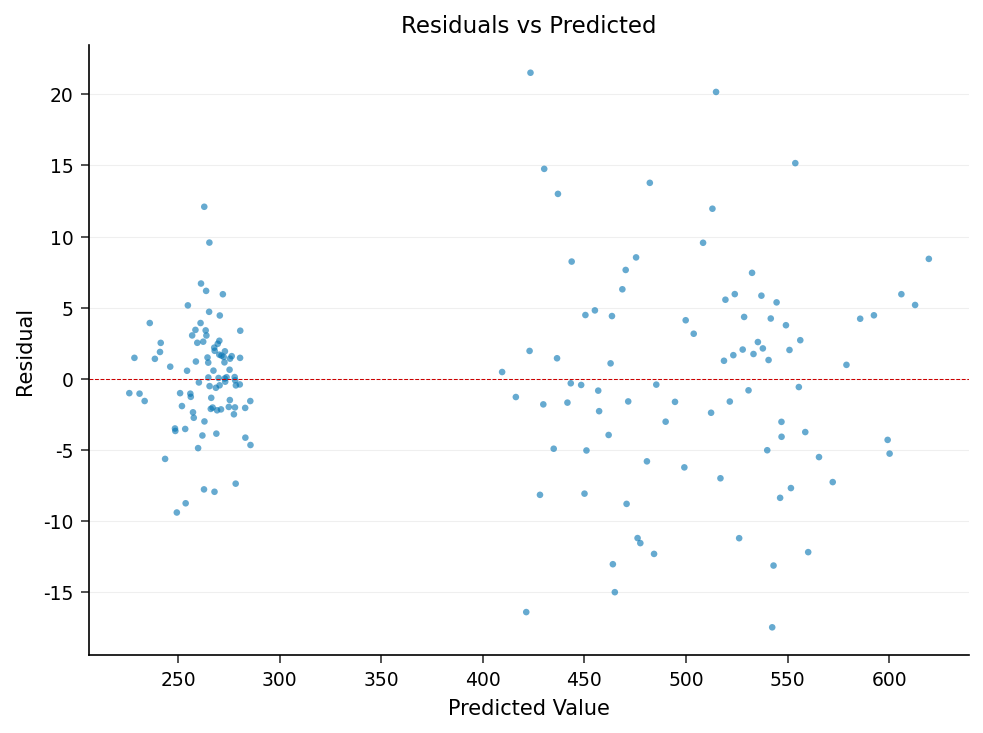

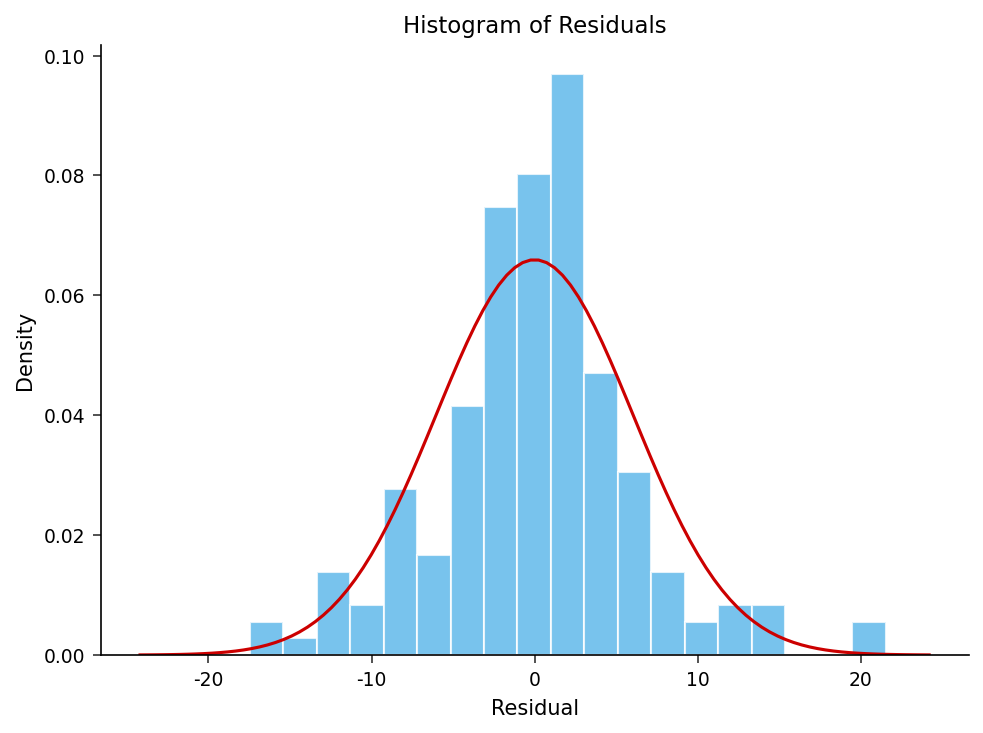

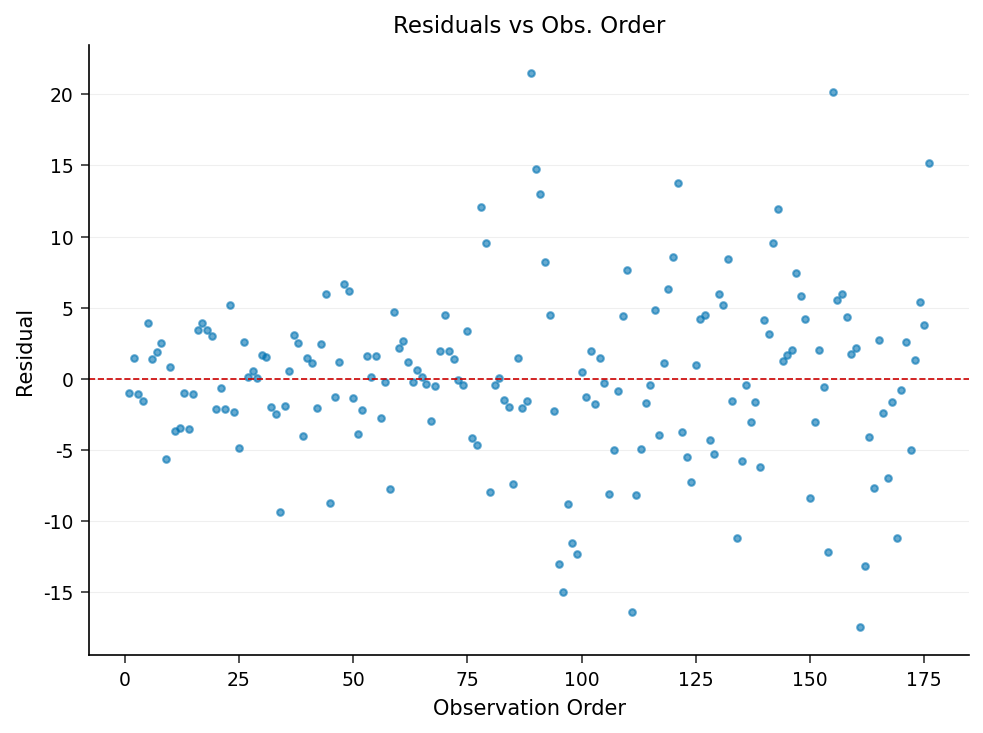

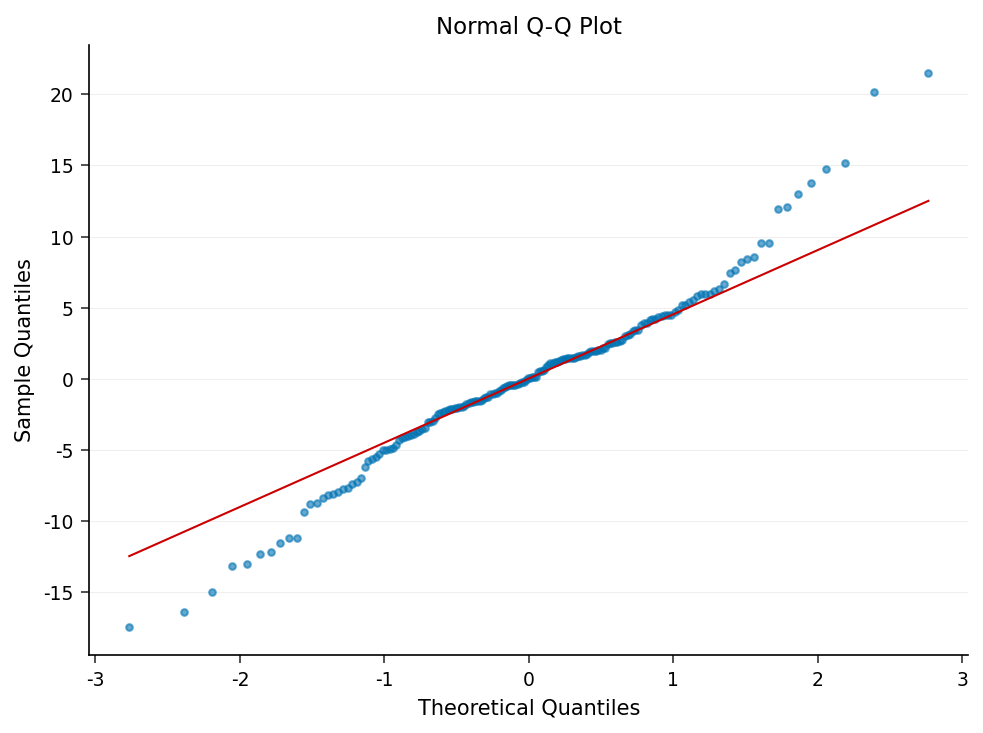

In [4]:
/* Model B: a random intercept per rat.
   Each rat gets its own level; the induced within-rat
   structure is compound symmetry (one shared correlation). */
proc mixed data=rats method=reml;
    class diet rat;
    model weight = time diet time*diet;
    random intercept / subject=rat;
run;


**What the fit shows.** The random intercept splits the variance into
a **between-rat** component of **1339.91** and a **within-rat**
residual of **41.02**. The share that is between-rat -- the
intraclass correlation -- is $1339.91 / (1339.91 + 41.02) \approx
\mathbf{0.97}$: almost all of the spread is rats differing in overall
size, and that difference persists across the study, echoing the
near-unit AR(1) correlation from Model A.

The fixed effects agree with Model A -- **`time` F = 105.01**,
**`diet` F = 77.60**, **`time*diet` F = 51.08**, all highly
significant. Notice the denominator degrees of freedom: `diet` is
tested against **13.2** while `time` and the interaction get **157**.
`diet` is a between-rat contrast, judged against how much rats vary;
`time` acts within each rat, where the data are far richer. This
model's **AIC is 1236.25**.

The random-intercept fit also returns four residual diagnostic
panels. Residuals scatter randomly around zero against both the
predicted value and the observation order -- no trend, no funnel --
and their histogram is centered and roughly bell-shaped. The Normal
Q-Q plot tracks the reference line through the middle but bends away
at both ends, the signature of mildly heavy tails: a handful of
weighings sit farther from their fitted trajectory than a Gaussian
would predict. The REML inference above rests on reasonable, if not
textbook-perfect, assumptions.


## Interpreting the results

- **Different trajectories, not just levels.** The `time*diet`
  interaction is significant in both fits (p = 0.0005 under AR(1),
  p < 0.0001 under the random intercept), so the diets change growth
  *rate*, not only starting weight.
- **Serial correlation is near-perfect.** The AR(1) fit estimates a
  within-rat correlation of 0.9896; ignoring it would treat each
  rat's eleven weighings as eleven independent facts and overstate the
  precision of every effect.
- **The spread is between rats.** The random-intercept model puts an
  intraclass correlation of 0.97 on the data -- rats differ enormously
  in size, and a pooled OLS that ignored it would be badly
  overconfident.
- **Let fit statistics choose the structure.** The AR(1) model's AIC
  (1155.05) is well below the random-intercept model's (1236.25):
  here the correlation genuinely decays with the day gap rather than
  staying flat, so the time-series structure earns its place. Fit
  both and compare -- the covariance structure that matches your
  measurement process should win.

PROC MIXED fits each specification by REML and reports the covariance
parameters, fixed-effect tests, and fit statistics needed to choose
among them -- the standard toolkit for repeated-measures data.
